In [1]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [2]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML, display
import course_helpers as chh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="11-Backpropagation.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 39 cell(s):
 cell_index   slide_id                                  tags
          9  slide-1-0 slide_hide_prompt, slide_remove_input
         11  slide-1-1 slide_hide_prompt, slide_remove_input
         13  slide-2-0 slide_hide_prompt, slide_remove_input
         15  slide-2-1 slide_hide_prompt, slide_remove_input
         17  slide-2-2 slide_hide_prompt, slide_remove_input
         19  slide-3-0 slide_hide_prompt, slide_remove_input
         21  slide-3-1 slide_hide_prompt, slide_remove_input
         23  slide-3-2 slide_hide_prompt, slide_remove_input
         25  slide-3-3 slide_hide_prompt, slide_remove_input
         29  slide-4-2 slide_hide_prompt, slide_remove_input
         31  slide-4-3 slide_hide_prompt, slide_remove_input
         32  slide-4-3 slide_hide_prompt, slide_remove_input
         33  slide-4-3 slide_hide_prompt, slide_remove_input
         35  slide-4-4 slide_hide_prompt, slide_remove_input
         42  slide-6-0 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [4]:
# Every picture in this lecture is one of four shapes with
# different numbers alive on it, so each is a function here
# rather than seventy hand written cells.
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ---- palette, the one the other decks use ---------------------------------
MADRID = "#2A3B8F"      # the top path, the blue curve
ACCENT = "#D98A00"      # the bottom path, the orange curve
INK = "#1A1A1A"
GRIDCOL = "#C4C4D0"
FITLINE = "#B3121F"     # residuals, red marks, the unknown boxes
GREEN = "#2E8B57"       # the green squiggle and the output box
PINK = "#C2185B"        # the SSR curve and its dots
FADE = "#CBCEDA"        # anything greyed out

# ---- the network, with every parameter at the value the lecture uses ------
W1, B1 = 3.34, -1.43
W2, B2 = -3.53, 0.57
W3, W4 = -1.22, -2.30
B3_STAR = 2.61
DOSE = np.array([0.0, 0.5, 1.0])
OBS = np.array([0.0, 1.0, 0.0])


def softplus(x):
    return np.log(1.0 + np.exp(np.asarray(x, float)))


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, float)))


def x_top(d, w1=W1, b1=B1):
    return w1 * np.asarray(d, float) + b1


def x_bot(d, w2=W2, b2=B2):
    return w2 * np.asarray(d, float) + b2


def y_top(d, w1=W1, b1=B1):
    return softplus(x_top(d, w1, b1))


def y_bot(d, w2=W2, b2=B2):
    return softplus(x_bot(d, w2, b2))


def squiggle(d, b3, w3=W3, w4=W4, w1=W1, b1=B1, w2=W2, b2=B2):
    """The green squiggle: blue plus orange plus the final bias."""
    return w3 * y_top(d, w1, b1) + w4 * y_bot(d, w2, b2) + b3


def ssr_b3(b3, w3=W3, w4=W4):
    return float(np.sum((OBS - squiggle(DOSE, b3, w3, w4)) ** 2))


def ssr_w3(w3, w4=W4, b3=0.0):
    return float(np.sum((OBS - squiggle(DOSE, b3, w3, w4)) ** 2))


def _done(fig):
    """Hand the figure back ready to be displayed once. Closing it stops the
       inline backend drawing a second copy at the end of the cell."""
    plt.close(fig)
    return fig


def _frame(ax, xlab, ylab, xlim, ylim, xticks=None, yticks=None):
    ax.set_facecolor("white")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(INK)
    ax.spines["bottom"].set_color(INK)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.tick_params(labelsize=11, colors=INK)
    ax.set_xlabel(xlab, fontsize=12, color=INK)
    # y label sits flat above the axis, never rotated
    ax.text(0, 1.03, ylab, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=12, color=INK)


# ------------------------------------------------------- the dose-effect plot
def fig_curves(b3=0.0, w3=W3, w4=W4, show=("green",), residuals=False,
               points=True, ghost_b3=None, mark_dose=None, ylim=(-3.2, 1.6),
               title=None, figsize=(6.4, 4.2)):
    """Drug Effectiveness against Drug Dose: the blue curve, the orange curve,
       the green squiggle they add up to, the observed points, the residuals."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "Drug Dose", "Drug Effectiveness", (-0.05, 1.08), ylim,
           xticks=[0, 0.5, 1], yticks=[0, 1])
    d = np.linspace(0, 1, 400)

    if ghost_b3 is not None:
        ax.plot(d, squiggle(d, ghost_b3, w3, w4), color=GREEN, lw=2.6,
                alpha=0.28, zorder=3)
    if "blue" in show:
        ax.plot(d, w3 * y_top(d), color=MADRID, lw=3.0, zorder=4)
    if "orange" in show:
        ax.plot(d, w4 * y_bot(d), color=ACCENT, lw=3.0, zorder=4)
    if "green" in show:
        ax.plot(d, squiggle(d, b3, w3, w4), color=GREEN, lw=3.4, zorder=5)

    if residuals:
        for xi, oi in zip(DOSE, OBS):
            pi = float(squiggle(xi, b3, w3, w4))
            ax.plot([xi, xi], [oi, pi], color=FITLINE, lw=2.2, zorder=6)
    if points:
        ax.scatter(DOSE, OBS, s=150, color="#F2C200", edgecolors=INK, lw=1.6,
                   zorder=8)
    if mark_dose is not None:
        ax.scatter([mark_dose], [float(squiggle(mark_dose, b3, w3, w4))],
                   s=180, marker="o", facecolors="none", edgecolors=FITLINE,
                   lw=3, zorder=9)
    if title:
        ax.set_title(title, fontsize=13.5, color=MADRID, weight="bold", pad=26)
    fig.tight_layout()
    return _done(fig)


# ------------------------------------------------------------ the SSR curve
def fig_ssr(over="b3", dots=(), curve=False, tangent_at=(), ghost_dots=(),
            rings=(), arrow=None, mark=None, labels=(), xlim=None, ylim=None,
            title=None, figsize=(6.4, 4.2)):
    """SSR against whichever parameter we are optimizing."""
    if over == "b3":
        f, lab, lo, hi, top = ssr_b3, "$b_3$", -0.6, 5.6, 26
    else:
        f, lab, lo, hi, top = ssr_w3, "$w_3$", -3.2, 3.2, 14
    xlim = xlim or (lo, hi)
    ylim = ylim or (-top * 0.06, top)

    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, lab, "SSR", xlim, ylim,
           yticks=[round(top / 2), round(top)] if over == "b3" else [6, 12])
    w = np.linspace(xlim[0], xlim[1], 400)
    s = np.array([f(v) for v in w])

    if curve:
        ax.plot(w, s, color=PINK, lw=3.0, zorder=4)
    for v in ghost_dots:
        ax.scatter([v], [f(v)], s=120, color=PINK, alpha=0.3,
                   edgecolors="none", zorder=5)
    for v in dots:
        ax.scatter([v], [f(v)], s=130, color=PINK, edgecolors=INK, lw=1.2,
                   zorder=7)
    for v in tangent_at:
        h = 1e-5
        g = (f(v + h) - f(v - h)) / (2 * h)
        xx = np.linspace(v - (xlim[1] - xlim[0]) * 0.22,
                         v + (xlim[1] - xlim[0]) * 0.22, 40)
        yy = f(v) + g * (xx - v)
        keep = (yy >= ylim[0]) & (yy <= ylim[1])
        ax.plot(xx[keep], yy[keep], color=MADRID, lw=2.6, zorder=8)
    for v in rings:
        ax.scatter([v], [f(v)], s=150, marker="o", facecolors="none",
                   edgecolors=GREEN, lw=2.4, zorder=8)
    if mark is not None:
        ax.scatter([mark], [f(mark)], s=190, marker="o", facecolors="none",
                   edgecolors=GREEN, lw=3.2, zorder=9)
    for v, text, dx, dy in labels:
        ax.annotate(text, xy=(v, f(v)), xytext=(v + dx, f(v) + dy),
                    fontsize=10, color=INK, ha="center", zorder=10,
                    arrowprops=dict(arrowstyle="-", lw=1.0, color="#7A7A85",
                                    linestyle=":"))
    if arrow:
        x0, x1, y = arrow
        ax.annotate("", xy=(x1, y), xytext=(x0, y), zorder=9,
                    arrowprops=dict(arrowstyle="-|>", lw=2.2, color=FITLINE,
                                    linestyle=":"))
        ax.plot([x0], [y], marker="x", ms=13, mew=3.2, color=FITLINE, zorder=9)
    if title:
        ax.set_title(title, fontsize=13.5, color=MADRID, weight="bold", pad=26)
    fig.tight_layout()
    return _done(fig)


# ------------------------------------------------- the activation function
def fig_softplus(mark_x=None, show_derivative=False, x_label=None,
                 y_label=None, figsize=(5.6, 3.7)):
    """The SoftPlus curve, and on request the sigmoid that is its derivative.

       mark_x drops a dashed red line to each axis and labels both coordinates
       in red. The labels are nudged off the tick they sit nearest, because the
       pair we use lands either side of 2 on both axes."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "$x$", "", (-5, 5), (-0.4, 5.2), xticks=[-4, -2, 0, 2, 4])
    x = np.linspace(-5, 5, 400)
    ax.plot(x, softplus(x), color=MADRID, lw=3.2, zorder=5,
            label="SoftPlus, $\\log(1 + e^{x})$")
    if show_derivative:
        ax.plot(x, sigmoid(x), color=FITLINE, lw=2.8, zorder=5,
                label="its derivative, $\\dfrac{e^{x}}{1 + e^{x}}$")
    if mark_x is not None:
        my = float(softplus(mark_x))
        ax.plot([mark_x, mark_x], [-0.4, my], color=FITLINE, lw=1.8,
                ls=(0, (5, 4)), zorder=6)
        ax.plot([-5, mark_x], [my, my], color=FITLINE, lw=1.8,
                ls=(0, (5, 4)), zorder=6)
        ax.plot([mark_x], [my], marker="x", ms=14, mew=3.4, color=FITLINE,
                zorder=9)
        ax.text(mark_x + 0.28, -0.08, x_label or "$x = %.2f$" % mark_x,
                color=FITLINE, fontsize=12, ha="left", va="bottom", zorder=10,
                bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                          edgecolor="none"))
        ax.text(-4.75, my + 0.22, y_label or "$y = %.2f$" % my,
                color=FITLINE, fontsize=12, ha="left", va="bottom", zorder=10,
                bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                          edgecolor="none"))
    ax.legend(frameon=False, fontsize=11, loc="upper left")
    fig.tight_layout()
    return _done(fig)


# ------------------------------------------- the pictures drawn only once
def fig_local_minimum(figsize=(6.2, 3.8)):
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "parameter of interest", "SSR", (0, 10), (-0.3, 6.2),
           xticks=[], yticks=[])
    x = np.linspace(0.4, 9.6, 400)
    y = (4.0 - 2.6 * np.exp(-((x - 3.0) ** 2) / 1.2)
         - 1.5 * np.exp(-((x - 7.0) ** 2) / 1.0) + 0.05 * (x - 5.0) ** 2)
    ax.plot(x, y, color=PINK, lw=3.0, zorder=4)
    i_glob = int(np.argmin(np.where(x < 5.0, y, 9e9)))
    i_loc = int(np.argmin(np.where(x > 5.0, y, 9e9)))
    ax.annotate("a local minimum", xy=(x[i_loc], y[i_loc]), xytext=(7.9, 5.1),
                fontsize=11, color=INK, ha="center", zorder=9,
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#7A7A85",
                                linestyle=":"))
    ax.annotate("the global minimum", xy=(x[i_glob], y[i_glob]),
                xytext=(2.4, 4.0), fontsize=11, color=INK, ha="center",
                zorder=9,
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#7A7A85",
                                linestyle=":"))
    fig.tight_layout()
    return _done(fig)


def fig_cycle(figsize=(5.6, 3.6)):
    """The three steps gradient descent repeats."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    steps = [("a", "evaluate the derivative\nat the current value"),
             ("b", "multiply by the learning rate\nto get the step size"),
             ("c", "subtract the step size\nto get the new value")]
    for k, (letter, text) in enumerate(steps):
        y = 4.7 - k * 1.75
        ax.add_patch(plt.Circle((1.15, y), 0.42, facecolor="white",
                                edgecolor=GREEN, lw=2.4, zorder=5))
        ax.text(1.15, y, letter, ha="center", va="center", fontsize=13,
                weight="bold", color=INK, zorder=6)
        ax.text(2.0, y, text, ha="left", va="center", fontsize=11, color=INK)
        if k < 2:
            ax.annotate("", xy=(1.15, y - 1.33), xytext=(1.15, y - 0.45),
                        arrowprops=dict(arrowstyle="-|>", lw=2.0, color=GREEN))
    ax.annotate("", xy=(1.15, 4.25), xytext=(0.32, 1.2),
                arrowprops=dict(arrowstyle="-|>", lw=2.0, color=GREEN,
                                connectionstyle="arc3,rad=0.55"))
    ax.text(0.05, 2.9, "repeat", rotation=90, ha="center", va="center",
            fontsize=10.5, color=GREEN, weight="bold")
    fig.tight_layout()
    return _done(fig)


_LW = np.array([0.6, 1.3, 2.0, 2.6, 3.1])
_LH = np.array([1.3, 1.6, 2.2, 2.4, 3.0])
_LINES = {"start": (3.4, -0.55), "middle": (1.0, 0.45), "end": (0.95, 0.64)}


def fig_line_fit(stage, figsize=(5.0, 3.6)):
    """Fitting a line: a bad guess, a better one, and the fit."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "Weight", "Height", (0, 3.6), (0, 3.6), xticks=[], yticks=[])
    x = np.linspace(0, 3.6, 50)
    order = ["start", "middle", "end"]
    for earlier in order[:order.index(stage)]:
        a, b = _LINES[earlier]
        ax.plot(x, a + b * x, color=PINK, lw=2.4, alpha=0.25, zorder=3)
    a, b = _LINES[stage]
    ax.plot(x, a + b * x, color=MADRID if stage == "end" else PINK, lw=3.2,
            zorder=5)
    for xi, yi in zip(_LW, _LH):
        ax.plot([xi, xi], [yi, a + b * xi], color=GREEN, lw=2.0, zorder=4)
    ax.scatter(_LW, _LH, s=130, color="#E8879C", edgecolors=INK, lw=1.4,
               zorder=8)
    fig.tight_layout()
    return _done(fig)


# ------------------------------------------------------------- the network
def fig_network(w1=W1, b1=B1, w2=W2, b2=B2, w3=W3, w4=W4, b3=B3_STAR,
                labels=False, ring=(), awake="both", backward_arrow=False,
                input_val=None, output_val=None, unoptimized=(), title=None,
                figsize=(8.4, 4.2)):
    """The seven parameter network. Any parameter can be given the string
       '???' and it prints that instead of a number, which is how the unknowns
       are shown. ring names the boxes to circle: w1 b1 w2 b2 w3 w4 b3."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(0, 13.2)
    ax.set_ylim(0.1, 6.0)

    ct = MADRID if awake in ("top", "both") else FADE
    cb = ACCENT if awake in ("bottom", "both") else FADE

    def txt(v, op="x"):
        if isinstance(v, str):
            return "%s %s" % (op, v)
        return "%s %g" % (op, v)

    _VALUES = dict(w1=w1, b1=b1, w2=w2, b2=b2, w3=w3, w4=w4, b3=b3)

    def value_colour(key, path_colour):
        """Optimized parameters print green, unoptimized ones red. A parameter
           still showing ??? has not been optimized either."""
        if path_colour == FADE:
            return FADE
        if key in unoptimized or isinstance(_VALUES[key], str):
            return FITLINE
        return GREEN

    def pbox(x, y, text, colour, key, fs=10.5):
        boxed = key in ring
        ax.text(x, y, text, ha="center", va="center", fontsize=fs,
                color=value_colour(key, colour), zorder=8,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                          edgecolor=FITLINE if boxed else "none", linewidth=2.0,
                          linestyle=(0, (1.5, 1.5)) if boxed else "-"))

    def arrow(p0, p1, c, lw=2.0):
        ax.annotate("", xy=p1, xytext=p0, zorder=3,
                    arrowprops=dict(arrowstyle="-|>", lw=lw, color=c))

    def at(p0, p1, f):
        return (p0[0] + f * (p1[0] - p0[0]), p0[1] + f * (p1[1] - p0[1]))

    def act_panel(x, y, c, w=1.5, h=1.2):
        """A SoftPlus panel: a curve, not a bend."""
        ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, zorder=4,
                                   facecolor="white", edgecolor=c, lw=2.4))
        t = np.linspace(-3.2, 2.6, 120)
        s = softplus(t)
        ax.plot(x + (t / 3.2) * (w * 0.36),
                y - h * 0.32 + (s / 3.0) * (h * 0.60), color=c, lw=2.2,
                zorder=5)

    # input
    ax.add_patch(plt.Rectangle((0.35, 2.45), 1.5, 1.1, zorder=4,
                               facecolor="white", edgecolor=INK, lw=2.2))
    ax.text(1.1, 2.15, "Dose\n(Input)", ha="center", va="top", fontsize=10,
            color=INK)
    if input_val is not None:
        ax.text(1.1, 3.0, "%g" % input_val, ha="center", va="center",
                fontsize=17, weight="bold", color=FITLINE, zorder=6)

    tp, bp = (1.95, 3.25), (1.95, 2.75)
    ta, ba = (4.55, 4.60), (4.55, 1.45)
    arrow(tp, ta, ct)
    arrow(bp, ba, cb)
    pbox(*at(tp, ta, 0.26), txt(w1), ct, "w1")
    pbox(*at(tp, ta, 0.68), txt(b1, "+"), ct, "b1")
    pbox(*at(bp, ba, 0.26), txt(w2), cb, "w2")
    pbox(*at(bp, ba, 0.68), txt(b2, "+"), cb, "b2")
    if labels:
        for p0, p1, f, name, dy in ((tp, ta, 0.26, "$w_1$", 0.52),
                                    (tp, ta, 0.68, "$b_1$", 0.52),
                                    (bp, ba, 0.26, "$w_2$", -0.55),
                                    (bp, ba, 0.68, "$b_2$", -0.55)):
            ax.text(at(p0, p1, f)[0], at(p0, p1, f)[1] + dy, name,
                    ha="center", fontsize=11, color=INK, weight="bold")

    act_panel(5.35, 4.62, ct)
    act_panel(5.35, 1.43, cb)

    to, bo = (6.15, 4.62), (6.15, 1.43)
    sm = (8.45, 3.02)
    arrow(to, (7.85, 3.30), ct)
    arrow(bo, (7.85, 2.74), cb)
    pbox(*at(to, (7.85, 3.30), 0.46), txt(w3), ct, "w3")
    pbox(*at(bo, (7.85, 2.74), 0.46), txt(w4), cb, "w4")
    if labels:
        ax.text(at(to, (7.85, 3.30), 0.46)[0],
                at(to, (7.85, 3.30), 0.46)[1] + 0.52, "$w_3$", ha="center",
                fontsize=11, color=INK, weight="bold")
        ax.text(at(bo, (7.85, 2.74), 0.46)[0],
                at(bo, (7.85, 2.74), 0.46)[1] - 0.55, "$w_4$", ha="center",
                fontsize=11, color=INK, weight="bold")

    # sum, then the final bias, then the output
    ax.text(sm[0], sm[1], "sum", ha="center", va="center", fontsize=11,
            style="italic", color=INK, zorder=5)
    pbox(9.75, 3.02, txt(b3, "+"), INK, "b3", fs=11)
    if labels:
        ax.text(9.75, 3.62, "$b_3$", ha="center", fontsize=11, color=INK,
                weight="bold")
    arrow((9.02, 3.02), (9.28, 3.02), INK, lw=1.8)
    arrow((10.35, 3.02), (10.75, 3.02), INK, lw=1.8)
    ax.add_patch(plt.Rectangle((10.95, 2.47), 1.7, 1.1, zorder=4,
                               facecolor="white", edgecolor=GREEN, lw=2.2))
    ax.text(11.8, 2.17, "Effectiveness\n(Output)", ha="center", va="top",
            fontsize=10, color=INK)
    if output_val is not None:
        ax.text(11.8, 3.02, "%g" % output_val, ha="center", va="center",
                fontsize=17, weight="bold", color=FITLINE, zorder=6)

    if backward_arrow:
        ax.annotate("", xy=(2.2, 5.62), xytext=(11.0, 5.62), zorder=9,
                    arrowprops=dict(arrowstyle="-|>", lw=3.0, color="#6E6E78"))
        ax.text(6.6, 5.78,
                "the gradient is worked out from the back to the front",
                ha="center", fontsize=10, color="#4A4A52")

    if title:
        ax.set_title(title, fontsize=13.5, color=MADRID, weight="bold", pad=14)
    fig.tight_layout()
    return _done(fig)


# ===================================================== the ReLU comparison
# A second activation, so we can show what changes when the function has a
# corner in it. These use the parameter set that fits this data under ReLU.
RW1, RB1 = 1.43, -0.61
RW2, RB2 = 2.63, -0.27
RW3, RW4 = -3.89, 1.35


def relu(x):
    return np.maximum(np.asarray(x, float), 0.0)


def relu_step(x):
    """The derivative of ReLU. Undefined at the corner, defined as 1 there."""
    return (np.asarray(x, float) >= 0).astype(float)


def fig_two_activations(figsize=(8.6, 3.6)):
    """SoftPlus and ReLU, each with its own derivative underneath it."""
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    x = np.linspace(-4, 4, 800)
    for ax, (name, f, fp) in zip(axes, [
            ("SoftPlus", softplus, sigmoid), ("ReLU", relu, relu_step)]):
        _frame(ax, "$x$", "", (-4, 4), (-0.45, 4.3), xticks=[-4, -2, 0, 2, 4],
               yticks=[0, 2, 4])
        ax.plot(x, f(x), color=MADRID, lw=3.0, zorder=5, label=name)
        ax.plot(x, fp(x), color=FITLINE, lw=2.6, zorder=5,
                label="its derivative")
        ax.set_title(name, fontsize=13, color=MADRID, weight="bold", pad=24)
        ax.legend(frameon=False, fontsize=10, loc="upper left")
    axes[1].plot([0], [0], marker="o", ms=11, mfc="none", mec=FITLINE, mew=2.6,
                 zorder=9)
    axes[1].annotate("no derivative\nhere", xy=(0, 0), xytext=(1.5, 2.6),
                     fontsize=10, color=INK, ha="center",
                     arrowprops=dict(arrowstyle="-|>", lw=1.3, color="#7A7A85",
                                     linestyle=":"))
    fig.tight_layout()
    return _done(fig)


def _ssr_over_b1(b1, act):
    p = RW3 * act(RW1 * DOSE + b1) + RW4 * act(RW2 * DOSE + RB2)
    return float(np.sum((OBS - p) ** 2))


def fig_loss_shape(figsize=(8.6, 3.7)):
    """The same sweep over b1 under each activation. ReLU corners where a data
       point crosses the bend; SoftPlus has no corners anywhere."""
    b = np.linspace(-2.3, 0.7, 1200)
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    for ax, (name, act) in zip(axes, [("ReLU", relu),
                                      ("SoftPlus", softplus)]):
        s = np.array([_ssr_over_b1(v, act) for v in b])
        _frame(ax, "$b_1$", "SSR", (-2.3, 0.7), (-0.4, max(s) * 1.12),
               xticks=[-2, -1, 0])
        ax.plot(b, s, color=PINK, lw=3.0, zorder=5)
        ax.set_title(name, fontsize=13, color=MADRID, weight="bold", pad=24)
        if name == "ReLU":
            for k in (-RW1 * 0.5, -RW1 * 1.0):
                ax.plot([k], [_ssr_over_b1(k, act)], marker="o", ms=10,
                        mfc="none", mec=FITLINE, mew=2.6, zorder=9)
            ax.annotate("corner", xy=(-RW1 * 1.0, _ssr_over_b1(-RW1, act)),
                        xytext=(-1.45, max(s) * 0.55), fontsize=10.5,
                        color=INK, ha="center",
                        arrowprops=dict(arrowstyle="-|>", lw=1.3,
                                        color="#7A7A85", linestyle=":"))
            ax.annotate("flat: the derivative is 0 here,\nso a step goes nowhere",
                        xy=(-2.05, _ssr_over_b1(-2.05, act)),
                        xytext=(-1.05, max(s) * 0.82), fontsize=10.5,
                        color=FITLINE, ha="center",
                        arrowprops=dict(arrowstyle="-|>", lw=1.4,
                                        color=FITLINE, linestyle=":"))
    fig.tight_layout()
    return _done(fig)

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Backpropagation

### How a network finds its weights and biases

Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Last Time: Neural Network Fundamentals

- A dose goes in, two nodes bend it, the bent pieces are scaled and added
- Each connection multiplies by a <b style="color:#73000A;">weight</b> and adds a <b style="color:#73000A;">bias</b>
- The activation function bends a straight line into a new shape
- We used a finished network, with every number already filled in

Today the activation function is <b style="color:#73000A;">SoftPlus</b> rather
than the ReLU, because we are about to differentiate it and SoftPlus is smooth.

### Where We Are Going

We never said where those numbers came from.

- Today: <b style="color:#73000A;">backpropagation</b>, the method that finds them
- Two steps: a derivative for each parameter, then walk downhill
- We already know the second step. That was gradient descent, lecture 5
- Act 1 optimizes <b style="color:#73000A;">one</b> parameter, act 2 does
  <b style="color:#73000A;">three</b>, act 3 does <b style="color:#73000A;">all seven</b>

## The Problem: Nobody Told Us the Parameters

Last lecture the network arrived with its weights and biases already filled in.

A network starts with identical activation functions. Different weights and
biases flip and stretch them into new shapes, which are added together to get a
squiggle that fits the data.

We never said where those numbers come from.

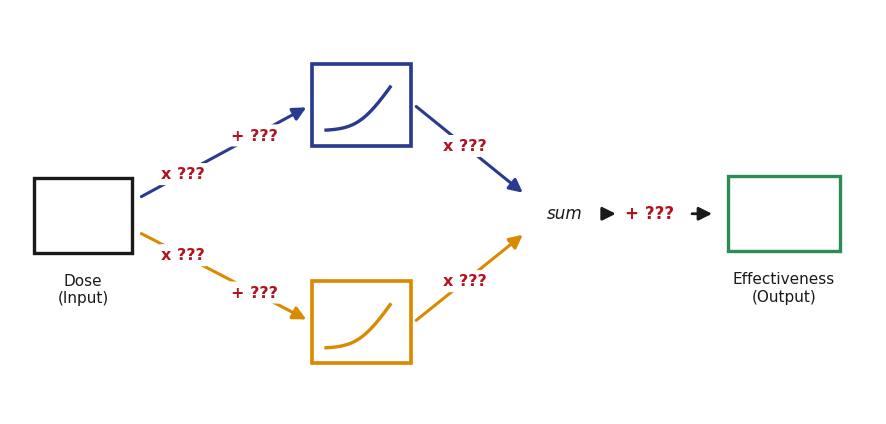

In [5]:
display(fig_network(w1='???', b1='???', w2='???', b2='???',
                    w3='???', w4='???', b3='???'))

### The Answer: Backpropagation

Two steps.

1. Use the <b style="color:#73000A;">chain rule</b> to calculate derivatives
2. Plug those derivatives into <b style="color:#73000A;">gradient descent</b> to
   optimize the parameters

The name comes from the order the derivatives are worked out in: from the back
of the network towards the front.

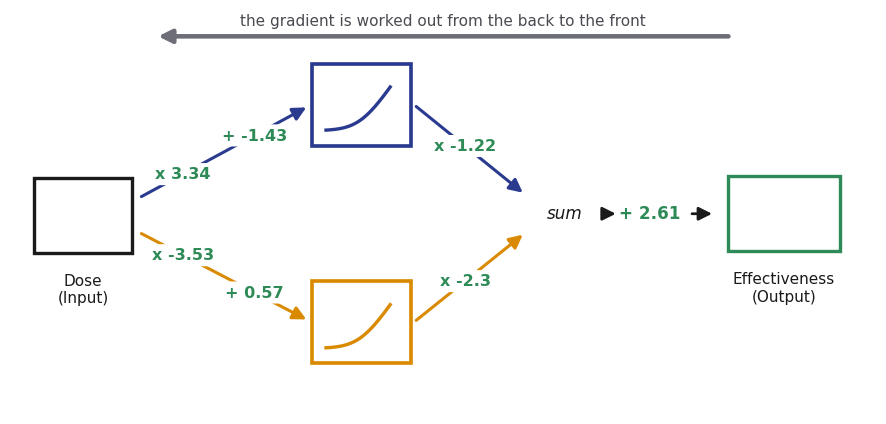

In [6]:
display(fig_network(backward_arrow=True))

## Name Every Parameter

So we can say which one we mean.

- The four we <b style="color:#73000A;">multiply</b> by are the weights,
  $w_1$, $w_2$, $w_3$, $w_4$
- The three we <b style="color:#73000A;">add</b> are the biases,
  $b_1$, $b_2$, $b_3$

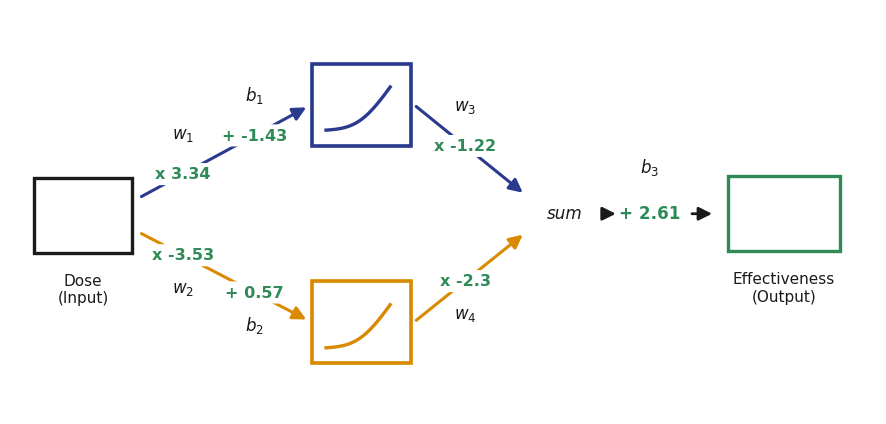

In [7]:
display(fig_network(labels=True))

### Start at the Back

 - Let's start with an easy example
   - Assume all parameters have been optimized except the last one.

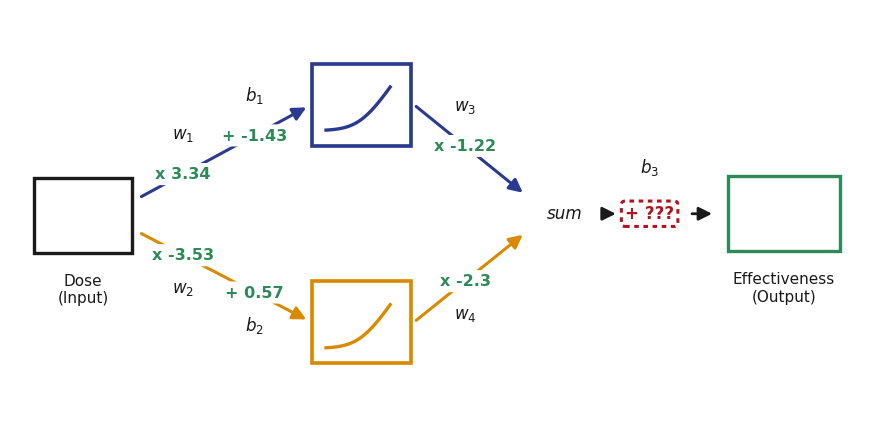

In [8]:
display(fig_network(labels=True, b3='???', ring=('b3',)))

### The Activation Function

To keep the arithmetic simple, doses run from $0$ for low to $1$ for high.

The activation function here is <b style="color:#73000A;">SoftPlus</b>.

$$\text{SoftPlus}(x) = \log\left(1 + e^{x}\right)$$

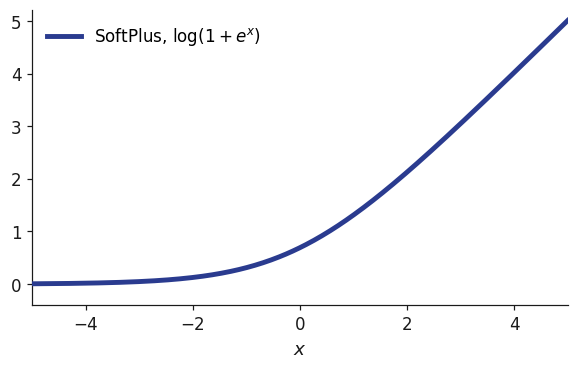

In [9]:
display(fig_softplus())

## Build the Green Squiggle

Run doses from $0$ to $1$ through the top of the network.

The x-axis coordinates go into the activation function, the y-axis coordinates
come out, and multiplying those by $w_3 = -1.22$ gives the final
<b style="color:#73000A;">blue curve</b>.

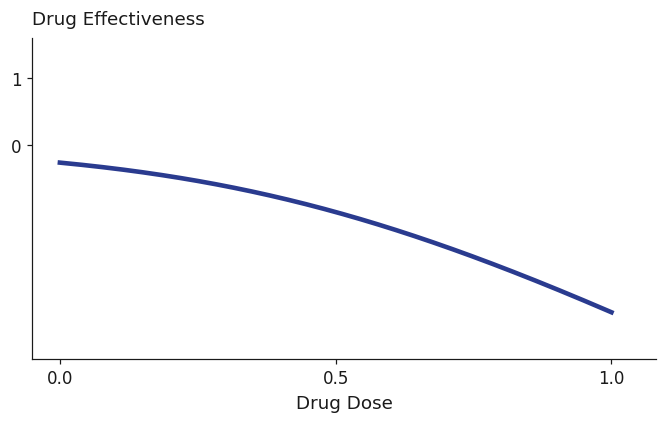

In [10]:
display(fig_curves(b3=0.0, show=('blue',), points=False))

### And the Bottom Half

Run the same doses through the bottom, then multiply by $w_4 = -2.30$ for the
final <b style="color:#73000A;">orange curve</b>.

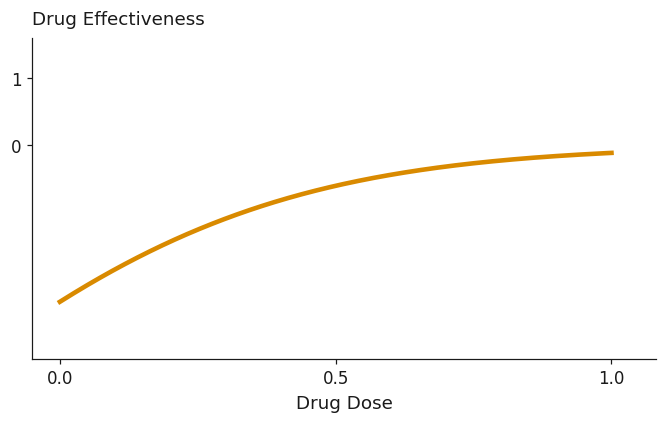

In [11]:
display(fig_curves(b3=0.0, show=('orange',), points=False))

### Add Them Together

Adding the blue and orange curves gives the
<b style="color:#73000A;">green squiggle</b>.

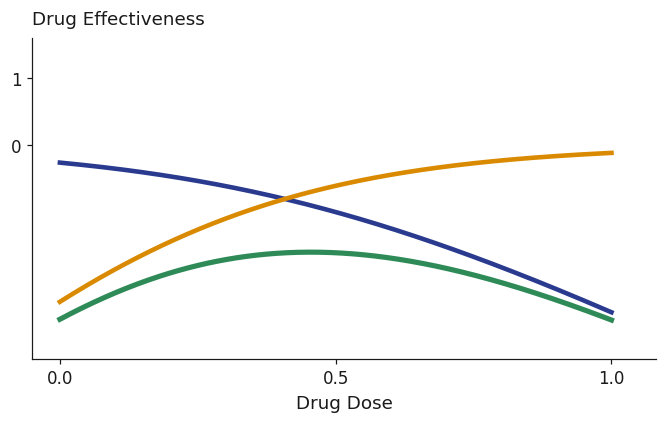

In [12]:
display(fig_curves(b3=0.0, show=('blue', 'orange', 'green'),
                   points=False))

### Now Add the Last Bias

We do not know the optimal $b_3$, so it needs a starting value.
  - Let's set $b_3 = 0$.

Leaves the squiggle where it is.

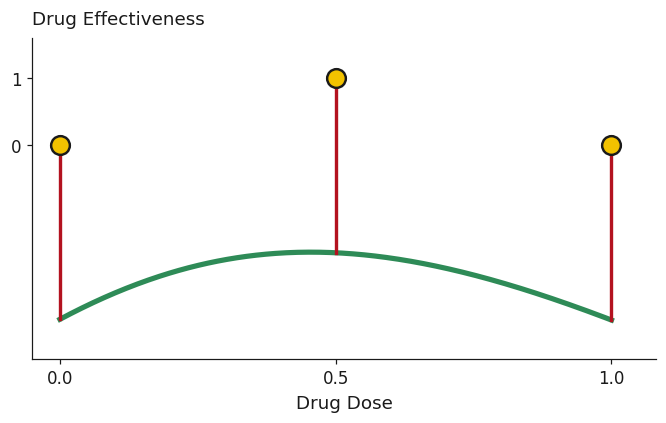

In [13]:
display(fig_curves(b3=0.0, residuals=True))

## Calculate the Residuals

$$\text{Residual} = \text{Observed} - \text{Predicted}$$

At the three doses the green squiggle predicts $-2.60$, $-1.61$ and $-2.61$.

### The Three Residuals

$$0 - (-2.60) = 2.60 \qquad
1 - (-1.61) = 2.61 \qquad
0 - (-2.61) = 2.61$$

Square each one and add them up.

$$\text{SSR} = 2.60^2 + 2.61^2 + 2.61^2 = \mathbf{20.4}$$

### Put That on a Graph

$b_3$ on the horizontal axis, the SSR it produces on the vertical.

When $b_3 = 0$, $\text{SSR} = 20.4$.

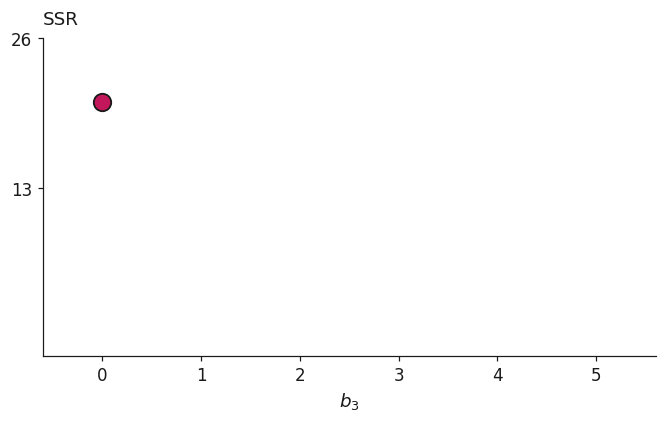

In [14]:
display(fig_ssr(over='b3', dots=[0.0]))

### Try Larger Values

Increasing $b_3$ shifts the whole squiggle up, and the residuals shrink.

<table style="width:auto; border-collapse:collapse; margin:0.7em 0 0 0;">
<tr>
  <th style="text-align:left;  padding:0.15em 1.8em 0.15em 0.2em; border-bottom:2px solid #333;"><i>b</i><sub>3</sub></th>
  <th style="text-align:right; padding:0.15em 0.2em;              border-bottom:2px solid #333;">SSR</th>
</tr>
<tr><td style="padding:0.15em 1.8em 0.15em 0.2em;">0</td><td style="text-align:right; padding:0.15em 0.2em;">20.4</td></tr>
<tr><td style="padding:0.15em 1.8em 0.15em 0.2em;">1</td><td style="text-align:right; padding:0.15em 0.2em;">7.8</td></tr>
<tr><td style="padding:0.15em 1.8em 0.15em 0.2em;">2</td><td style="text-align:right; padding:0.15em 0.2em;">1.11</td></tr>
<tr><td style="padding:0.15em 1.8em 0.15em 0.2em;">3</td><td style="text-align:right; padding:0.15em 0.2em;">0.46</td></tr>
</table>

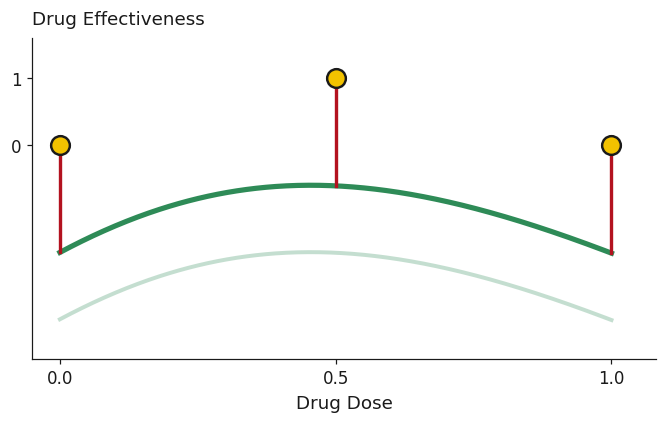

In [15]:
display(fig_curves(b3=1.0, residuals=True, ghost_b3=0.0))

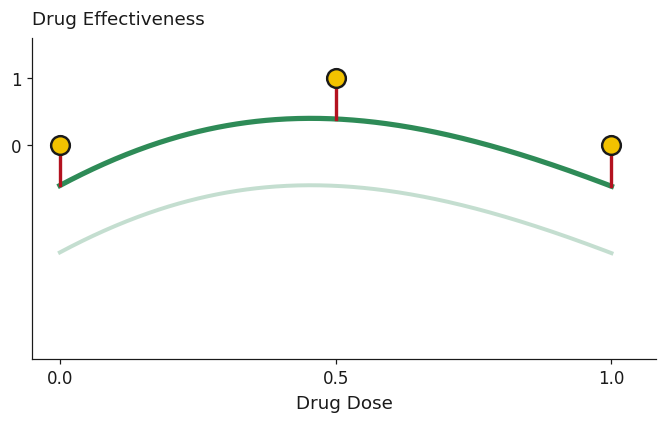

In [16]:
display(fig_curves(b3=2.0, residuals=True, ghost_b3=1.0))

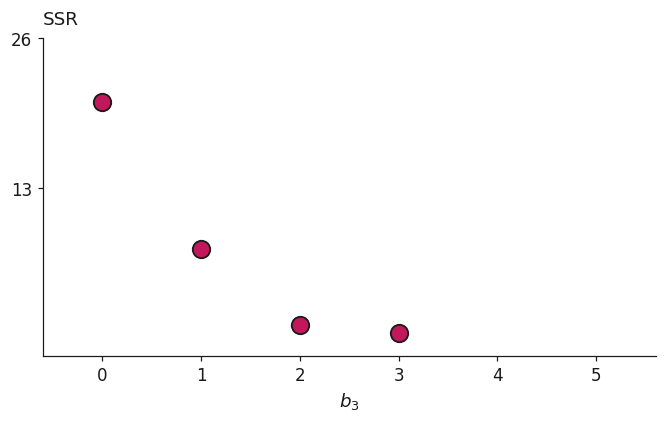

In [17]:
display(fig_ssr(over='b3', dots=[0, 1, 2, 3]))

### The Whole Curve

Plug in enough values for $b_3$ and we get this pink curve, with a lowest point.

Rather than try an infinite number of values, use **gradient descent** to find that
point quickly.

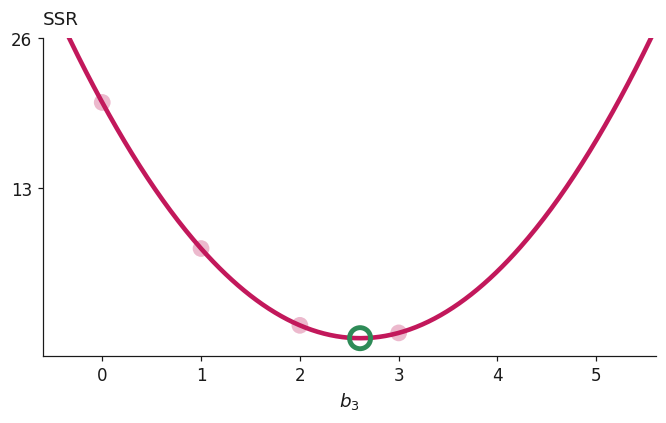

In [18]:
display(fig_ssr(over='b3', curve=True,
                ghost_dots=[0, 1, 2, 3], mark=2.6092))

## So We Need a Derivative

We need the derivative of the SSR with respect to $b_3$.

Start from what the SSR is.

$$\text{SSR} = (\text{Observed}_1 - \text{Predicted}_1)^2 +
(\text{Observed}_2 - \text{Predicted}_2)^2 +
(\text{Observed}_3 - \text{Predicted}_3)^2$$

or...

$$\text{SSR} = \sum_{i=1}^{n}
(\text{Observed}_i - \text{Predicted}_i)^2$$

Where... $$\text{Predicted} = \text{green curve} = \text{blue curve} +
\text{orange curve} + b_3$$

### The Chain Rule

The SSR is linked to $b_3$ by the predicted values, so

$$\frac{d\,\text{SSR}}{d\,b_3} =
\frac{d\,\text{SSR}}{d\,\text{Predicted}} \times
\frac{d\,\text{Predicted}}{d\,b_3}$$


### Find the Derivative

Substitute the equation for the SSR, bring the square to the front, and multiply
by the derivative of what is inside the parentheses.

$$\frac{d\,\text{SSR}}{d\,\text{Predicted}} =
\frac{d}{d\,\text{Predicted}} \sum
(\text{Observed}_i - \text{Predicted}_i)^2
= \sum 2 \times (\text{Observed}_i - \text{Predicted}_i) \times (-1)$$



$$= \sum -2 \times (\text{Observed}_i - \text{Predicted}_i)$$

### Piece Two

Substitute the equation for the predicted values.

$$\frac{d\,\text{Predicted}}{d\,b_3} =
\frac{d}{d\,b_3}\left[\text{blue curve} + \text{orange curve} +
b_3\right]$$

- The blue curve was made before we got to $b_3$, so its derivative is $0$
- The orange curve, the same, $0$
- And the derivative of $b_3$ with respect to $b_3$ is $1$

$$= 0 + 0 + 1 = 1$$

### Put Them Together

$$\frac{d\,\text{SSR}}{d\,b_3} =
\sum -2 \times (\text{Observed}_i - \text{Predicted}_i) \times 1$$

The $\times 1$ does nothing, but leave it there as a reminder that this
derivative is built from two parts.

## Walk Downhill

Expand the summation, then plug in the observed values and the values the green
squiggle predicts.

$$\frac{d\,\text{SSR}}{d\,b_3} =
-2(0 - (-2.60)) + -2(1 - (-1.61)) + -2(0 - (-2.61)) = \mathbf{-15.7}$$

That is the slope when $b_3 = 0$.

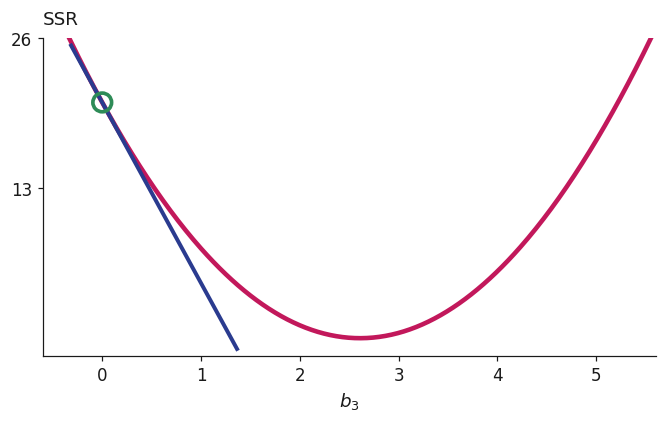

In [19]:
display(fig_ssr(over='b3', curve=True, tangent_at=[0.0],
                rings=[0.0]))

### Step Size and Learning Rate

$$\text{Step Size} = \text{Slope} \times \text{Learning Rate}
= -15.7 \times 0.1 = -1.57$$

$$\text{New } b_3 = \text{Old } b_3 - \text{Step Size}
= 0 - (-1.57) = \mathbf{1.57}$$

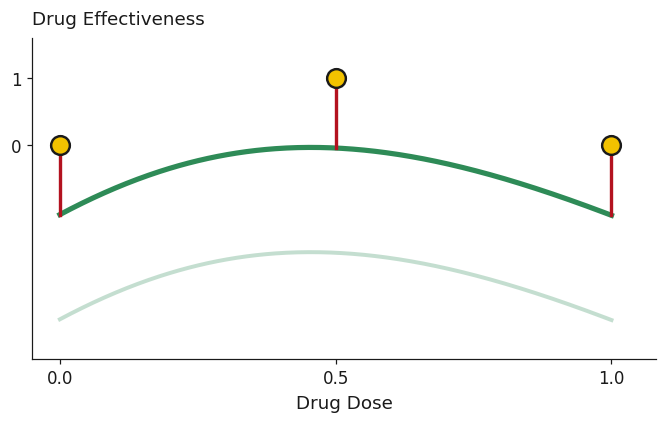

In [20]:
display(fig_curves(b3=1.5655, residuals=True, ghost_b3=0.0))

### Again

At $b_3 = 1.57$ the slope is $-6.26$, so the step is $-0.63$ and the new $b_3$
is $\mathbf{2.19}$.

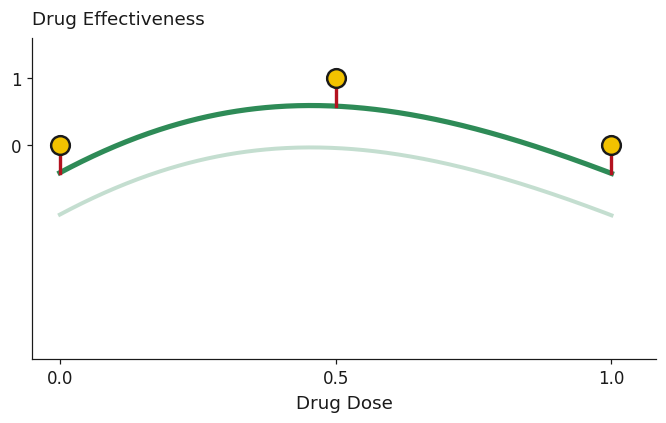

In [21]:
display(fig_curves(b3=2.1917, residuals=True, ghost_b3=1.5655))

### Keep Going

Take steps until the step size is close to zero.

That happens at $b_3 = \mathbf{2.61}$, so we call that optimal.

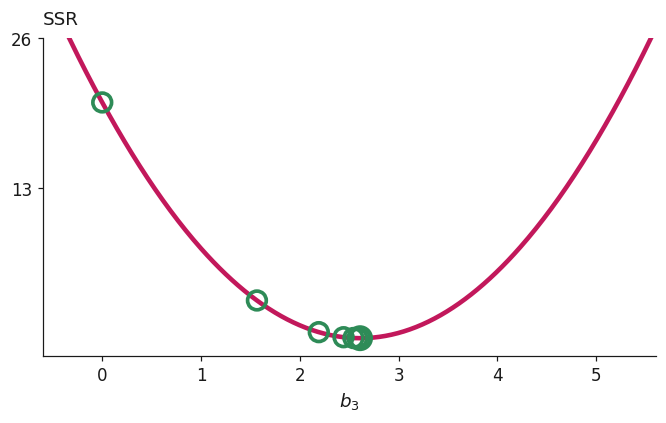

In [22]:
display(fig_ssr(over='b3', curve=True,
                rings=[0, 1.5655, 2.1917, 2.4422, 2.5424, 2.5825],
                mark=2.6092))

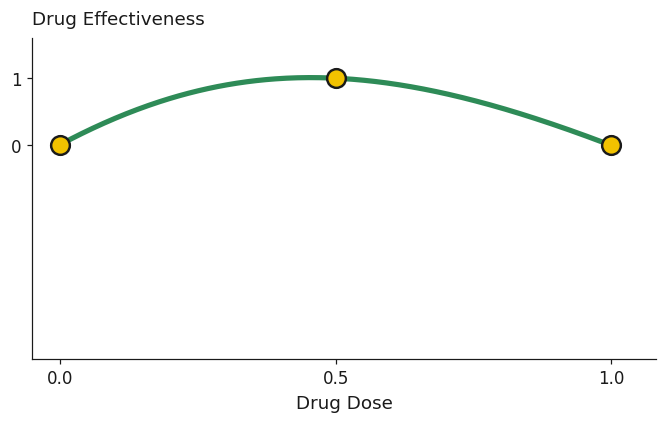

In [23]:
display(fig_curves(b3=2.6092, residuals=True))

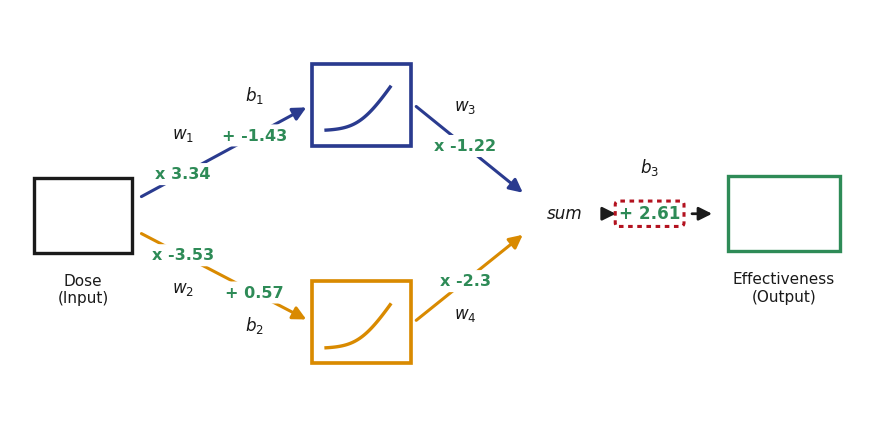

In [24]:
display(fig_network(labels=True, b3=2.61, ring=('b3',)))

### The Main Ideas

When a parameter is unknown, like $b_3$:

1. Use the <b style="color:#73000A;">chain rule</b> to get the derivative of the
   SSR with respect to it
2. <b style="color:#73000A;">Initialize</b> it with a number, here $0$
3. Use <b style="color:#73000A;">gradient descent</b> to optimize it

Everything that follows is those three steps, applied to more parameters.

# Act 2

## Three Parameters at Once

## Now Forget $w_3$ and $w_4$ As Well

Along with $b_3$, pretend we do not know the last two weights either.

Everything earlier in the network stays at its optimal value.

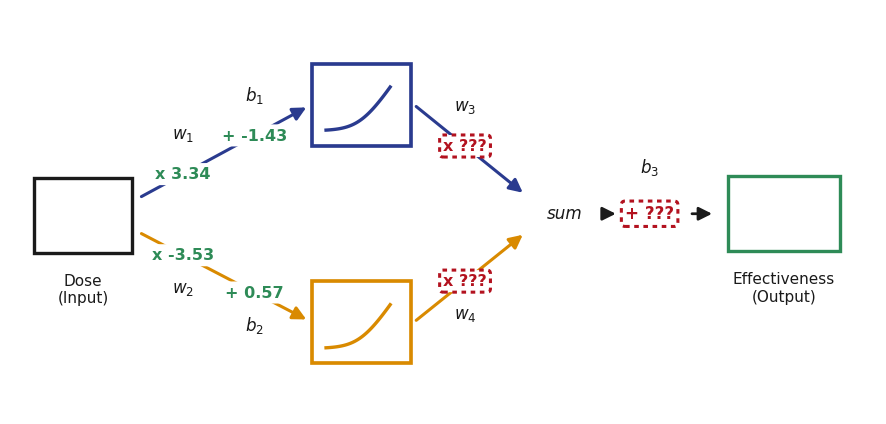

In [25]:
display(fig_network(labels=True, w3='???', w4='???', b3='???',
                    ring=('w3', 'w4', 'b3')))

### Initialize Them

- The weights get random starting values, drawn from a standard normal:
  $w_3 = 0.36$ and $w_4 = 0.63$
- The bias starts at zero, $b_3 = 0$

Drawing weights from a standard normal is one of several ways to initialize
them.

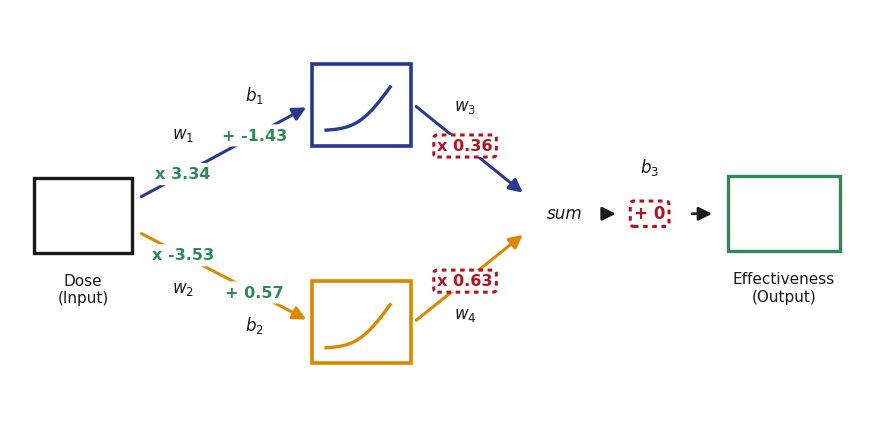

In [26]:
display(fig_network(labels=True, w3=0.36, w4=0.63, b3=0.0,
                    unoptimized=('w3', 'w4', 'b3'),
                    ring=('w3', 'w4', 'b3')))

### What Those Values Give Us

Multiply the top curve by $w_3 = 0.36$, the bottom by $w_4 = 0.63$, add them,
then add $b_3 = 0$.

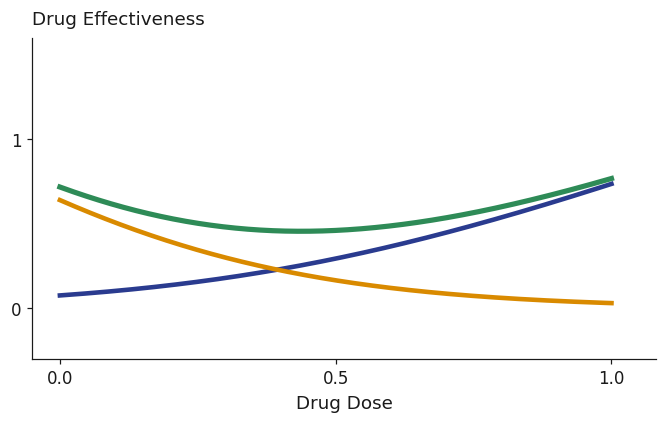

In [27]:
display(fig_curves(b3=0.0, w3=0.36, w4=0.63,
                   show=('blue', 'orange', 'green'), points=False,
                   ylim=(-0.3, 1.6)))

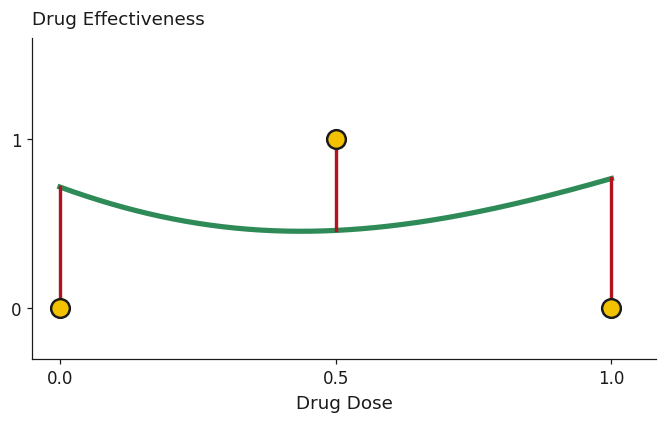

In [28]:
display(fig_curves(b3=0.0, w3=0.36, w4=0.63, residuals=True,
                   ylim=(-0.3, 1.6)))

### The SSR Here

$$\text{SSR} = \mathbf{1.4}$$

Even though $w_3$ and $w_4$ are not optimized, we can still plot the SSR against
$b_3$ and optimize it the same way as before.

### And the $b_3$ Derivative Has Not Changed

$$\frac{d\,\text{SSR}}{d\,b_3} =
\frac{d\,\text{SSR}}{d\,\text{Predicted}} \times
\frac{d\,\text{Predicted}}{d\,b_3}$$

This is the same derivative we worked out in act 1.

Optimizing more than one parameter does not change the derivatives we already
have.

### Coordinates Into the Activation Functions

The top connection multiplies $\text{Input}_i$ by $w_1$ and adds $b_1$:

$$x_{1,i} = (\text{Input}_i \times w_1) + b_1$$

The bottom connection uses $w_2$ and $b_2$:

$$x_{2,i} = (\text{Input}_i \times w_2) + b_2$$

The first subscript says which activation function, the second says which dose.

### For Example, the Highest Dose

At $i = 3$, $\text{Input}_3 = 1$, the maximum dose.

$$x_{1,3} = (1 \times 3.34) + (-1.43) = \mathbf{1.91}$$

$$x_{2,3} = (1 \times -3.53) + 0.57 = \mathbf{-2.96}$$

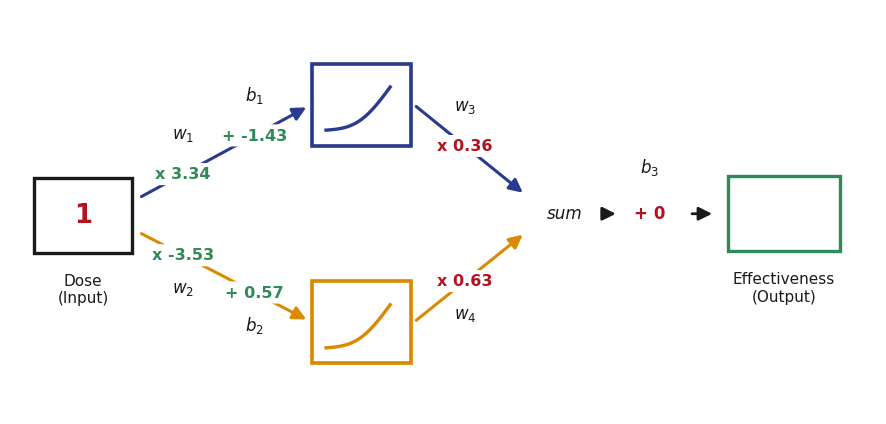

In [29]:
display(fig_network(labels=True, w3=0.36, w4=0.63, b3=0.0,
                    unoptimized=('w3', 'w4', 'b3'),
                    input_val=1.0))

### And the Coordinates Coming Out

Plug each one into the activation function.

$$y_{1,i} = \text{SoftPlus}(x_{1,i}) \qquad
y_{2,i} = \text{SoftPlus}(x_{2,i})$$


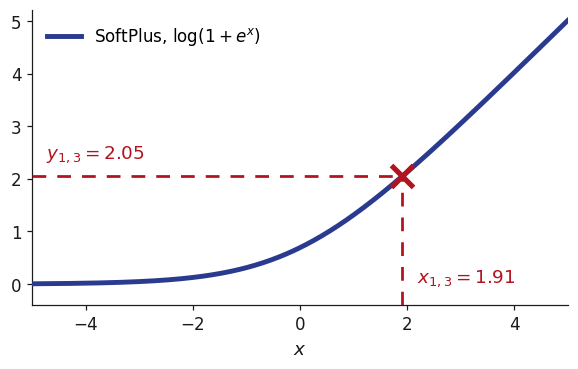

In [30]:
display(fig_softplus(mark_x=1.91,
                     x_label=r'$x_{1,3} = 1.91$',
                     y_label=r'$y_{1,3} = 2.05$'))

## The Derivatives for $w_3$ and $w_4$

$y_{1,i}$ multiplied by $w_3$ makes the final blue curve, and $y_{2,i}$
multiplied by $w_4$ makes the final orange curve.

So the predicted values are

$$\text{Predicted}_i = (y_{1,i} \times w_3) + (y_{2,i} \times w_4) + b_3$$

### Chain Rule, Same Shape as Before

$$\frac{d\,\text{SSR}}{d\,w_3} =
\frac{d\,\text{SSR}}{d\,\text{Predicted}} \times
\frac{d\,\text{Predicted}}{d\,w_3}$$

$$\frac{d\,\text{SSR}}{d\,w_4} =
\frac{d\,\text{SSR}}{d\,\text{Predicted}} \times
\frac{d\,\text{Predicted}}{d\,w_4}$$

We already have the first part...

### The Second Factors

$$\frac{d\,\text{Predicted}}{d\,w_3} =
\frac{d}{d\,w_3}\left[(y_{1,i} \times w_3) + (y_{2,i} \times w_4) +
b_3\right] = y_{1,i} + 0 + 0 = y_{1,i}$$

$$\frac{d\,\text{Predicted}}{d\,w_4} = 0 + y_{2,i} + 0 = y_{2,i}$$

### So the Two Derivatives Are

$$\frac{d\,\text{SSR}}{d\,w_3} =
\sum -2 \times (\text{Observed}_i - \text{Predicted}_i) \times y_{1,i}$$

$$\frac{d\,\text{SSR}}{d\,w_4} =
\sum -2 \times (\text{Observed}_i - \text{Predicted}_i) \times y_{2,i}$$

The slot that held $\times 1$ for $b_3$ now holds the y-axis coordinate.

## Put Numbers In

Expand the summation, plug in the observed values, then run each dose through
the network to get the predictions and the $y_{1,i}$.

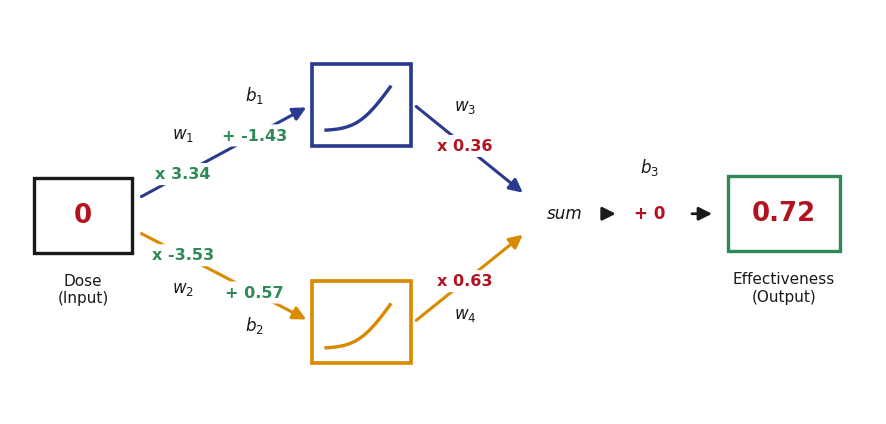

In [31]:
display(fig_network(labels=True, w3=0.36, w4=0.63, b3=0.0,
                    unoptimized=('w3', 'w4', 'b3'),
                    input_val=0.0, output_val=0.72))

### The Derivative With Respect to $w_3$

$$\frac{d\,\text{SSR}}{d\,w_3} = \mathbf{2.58}$$

Positive, so $w_3$ needs to move left, and by a fair amount.

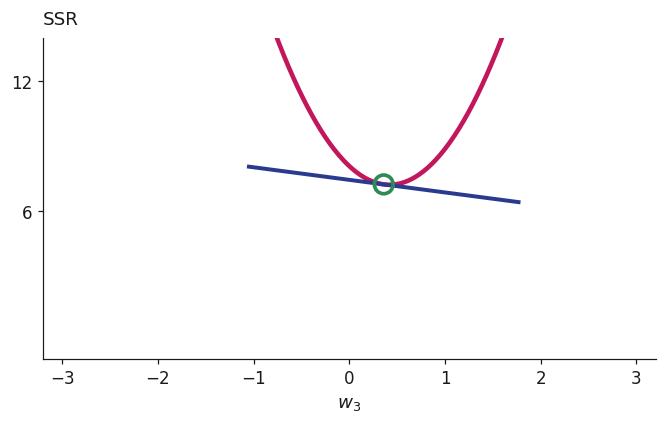

In [32]:
display(fig_ssr(over='w3', curve=True, tangent_at=[0.36],
                rings=[0.36]))

### Then the Same Three Steps

Each of the three parameters gets its own derivative, its own step size at the
same learning rate, and its own new value.

Then repeat until the predictions stop improving, or we hit a maximum number of
steps.

# Act 3

## Every Parameter at Once

## What Is Missing?

The derivatives for $b_3$, $w_3$ and $w_4$ do not change. We can use them as
they are.

What we still need are the four at the front:

$$\frac{d\,\text{SSR}}{d\,w_1} \qquad
\frac{d\,\text{SSR}}{d\,b_1} \qquad
\frac{d\,\text{SSR}}{d\,w_2} \qquad
\frac{d\,\text{SSR}}{d\,b_2}$$

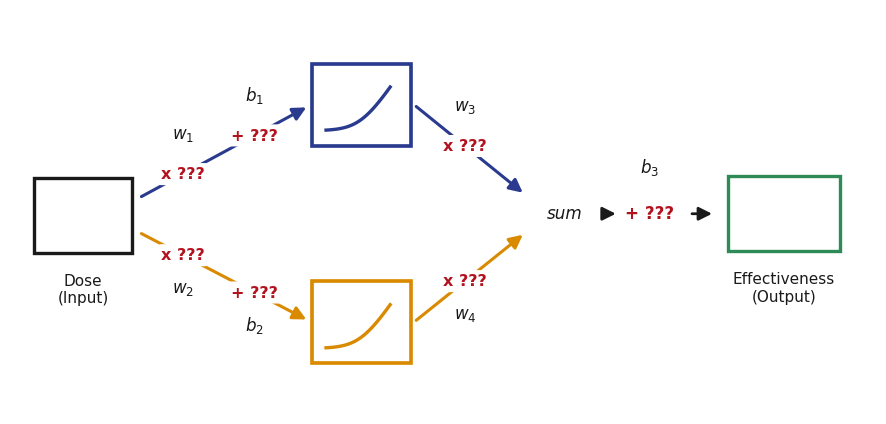

In [33]:
display(fig_network(labels=True, w1='???', b1='???', w2='???',
                    b2='???', w3='???', w4='???', b3='???'))

## Follow $w_1$ Forward

$w_1$ has a longer way to travel than $w_3$ did.

- $w_1$ multiplies the input, and $b_1$ is added, giving $x_{1,i}$
- $x_{1,i}$ goes through the activation function, giving $y_{1,i}$
- $y_{1,i}$ times $w_3$ makes the blue curve
- The blue curve, the orange curve and $b_3$ make the predicted values
- The predicted values give the SSR

Four links, so four factors.

### The Four Components

$$\frac{d\,\text{SSR}}{d\,w_1} =
\underbrace{\frac{d\,\text{SSR}}{d\,\text{Predicted}}}_{\text{(a)}}
\times
\underbrace{\frac{d\,\text{Predicted}}{d\,y_{1}}}_{\text{(b)}}
\times
\underbrace{\frac{d\,y_{1}}{d\,x_{1}}}_{\text{(c)}}
\times
\underbrace{\frac{d\,x_{1}}{d\,w_1}}_{\text{(d)}}$$

Take them one at a time.

### (a) Already Done

$$\frac{d\,\text{SSR}}{d\,\text{Predicted}} =
\sum -2 \times (\text{Observed}_i - \text{Predicted}_i)$$

Unchanged since act 1. It appears in all seven derivatives.

### (b) Predicted With Respect to $y_1$

$$\text{Predicted}_i = (y_{1,i} \times w_3) + (y_{2,i} \times w_4) + b_3$$

- The derivative of the first term with respect to $y_1$ is $w_3$
- The other two terms contain no $y_1$, so both are $0$

$$\frac{d\,\text{Predicted}}{d\,y_{1}} = w_3 + 0 + 0 = w_3$$

### (c) The Derivative of the Activation Function

$$y_{1,i} = \log\left(1 + e^{x_{1,i}}\right)$$

This needs two facts and one more chain rule:

- the derivative of $\log(z)$ is $\dfrac{1}{z}$
- the derivative of $e^{x}$ is $e^{x}$

### Work It Out

Let $z = 1 + e^{x}$. The chain rule gives the outside derivative times the
inside derivative.

$$\frac{d\,y_{1}}{d\,x_{1}} =
\underbrace{\frac{1}{1 + e^{x}}}_{\text{outside}} \times
\underbrace{\left(0 + e^{x}\right)}_{\text{inside}}
= \frac{e^{x}}{1 + e^{x}}$$

The $0$ is the derivative of the $1$, which does not contain $x$.

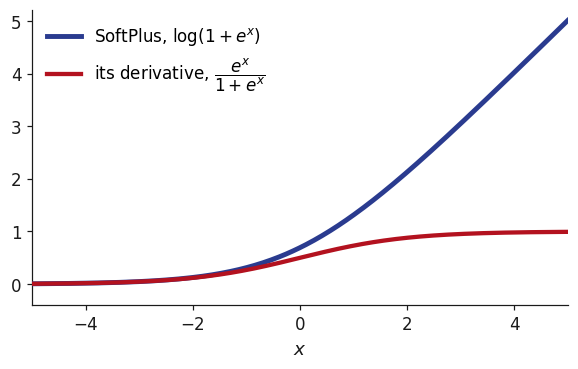

In [34]:
display(fig_softplus(show_derivative=True))

### (d) $x_1$ With Respect to $w_1$

$$x_{1,i} = (\text{Input}_i \times w_1) + b_1$$

- The derivative of the first term is $\text{Input}_i$
- The derivative of $b_1$ is $0$

$$\frac{d\,x_{1}}{d\,w_1} = \text{Input}_i + 0 = \text{Input}_i$$

### Put All Four Together

$$\frac{d\,\text{SSR}}{d\,w_1} =
\sum -2 (\text{Observed}_i - \text{Predicted}_i)
\times w_3
\times \frac{e^{x_{1,i}}}{1 + e^{x_{1,i}}}
\times \text{Input}_i$$

The $x$ in those exponentials is the x-axis coordinate for the top activation
function at that particular dose.

## $b_1$ Takes the Same Road

$b_1$ reaches the SSR through the same links as $w_1$: $x_1$, then
$y_1$, then the predicted values.

So three of the four factors are already done, and only the last one changes.

### Only the Last Factor

$$x_{1,i} = (\text{Input}_i \times w_1) + b_1$$

- The first term contains no $b_1$, so its derivative is $0$
- The derivative of $b_1$ is $1$

$$\frac{d\,x_{1}}{d\,b_1} = 0 + 1 = 1$$

$$\frac{d\,\text{SSR}}{d\,b_1} =
\sum -2 (\text{Observed}_i - \text{Predicted}_i)
\times w_3
\times \frac{e^{x_{1,i}}}{1 + e^{x_{1,i}}}
\times 1$$

## $w_2$ and $b_2$: Use the Bottom Node

The only real difference is that we now follow the bottom activation function,
so $x_2$ and $y_2$ replace $x_1$ and $y_1$, and $w_4$ replaces $w_3$.

$$\frac{d\,\text{SSR}}{d\,w_2} =
\sum -2 (\text{Observed}_i - \text{Predicted}_i)
\times w_4
\times \frac{e^{x_{2,i}}}{1 + e^{x_{2,i}}}
\times \text{Input}_i$$

$$\frac{d\,\text{SSR}}{d\,b_2} =
\sum -2 (\text{Observed}_i - \text{Predicted}_i)
\times w_4
\times \frac{e^{x_{2,i}}}{1 + e^{x_{2,i}}}
\times 1$$

### Nobody Does This by Hand

A derivative for every weight and bias is tedious, and a real network has
millions of them.

A library like PyTorch works out every one automatically.

We do it once, by hand, so we know what the library is doing.

## Run It on All Seven

 
$$w_1 = 3.34 \quad b_1 = -1.43 \quad w_2 = -3.53 \quad b_2 = 0.57$$

$$w_3 = 0.36 \quad w_4 = 0.63 \quad b_3 = 0$$

Starting SSR: $1.40$.

In [35]:
import numpy as np
import pandas as pd

dose = np.array([0.0, 0.5, 1.0])
observed = np.array([0.0, 1.0, 0.0])
p = dict(w1=3.34, b1=-1.43, w2=-3.53, b2=0.57, w3=0.36, w4=0.63, b3=0.0)


def pieces(p):
    x1 = p["w1"] * dose + p["b1"]
    x2 = p["w2"] * dose + p["b2"]
    y1, y2 = np.log(1 + np.exp(x1)), np.log(1 + np.exp(x2))
    return x1, y1, x2, y2, p["w3"] * y1 + p["w4"] * y2 + p["b3"]


def gradient(p):
    # the seven derivatives, as derived on the slides
    x1, y1, x2, y2, pred = pieces(p)
    front = -2 * (observed - pred)            # factor (a), in all seven
    s1 = np.exp(x1) / (1 + np.exp(x1))        # factor (c), top node
    s2 = np.exp(x2) / (1 + np.exp(x2))        # factor (c), bottom node
    return dict(w1=(front * p["w3"] * s1 * dose).sum(),
                b1=(front * p["w3"] * s1).sum(),
                w2=(front * p["w4"] * s2 * dose).sum(),
                b2=(front * p["w4"] * s2).sum(),
                w3=(front * y1).sum(),
                w4=(front * y2).sum(),
                b3=front.sum())


g = gradient(p)
display(pd.DataFrame([(k, p[k], g[k], 0.1 * g[k], p[k] - 0.1 * g[k])
                      for k in ("w1", "b1", "w2", "b2", "w3", "w4", "b3")],
                     columns=["parameter", "current", "derivative",
                              "step size", "new"]).round(4)
          .style.hide(axis="index"))

parameter,current,derivative,step size,new
w1,3.340000,0.373900,0.037400,3.302600
b1,-1.430000,0.365400,0.036500,-1.466500
w2,-3.530000,-0.031000,-0.003100,-3.526900
b2,0.570000,0.468700,0.046900,0.523100
w3,0.360000,2.576100,0.257600,0.102400
w4,0.630000,1.256800,0.125700,0.504300
b3,0.000000,1.899600,0.190000,-0.190000


### Then Repeat

Work out the seven derivatives at the new values, take seven more steps, and
keep going.

In [36]:
p = dict(w1=3.34, b1=-1.43, w2=-3.53, b2=0.57, w3=0.36, w4=0.63, b3=0.0)
trace = []
for step in range(1, 601):
    g = gradient(p)
    p = {k: p[k] - 0.1 * g[k] for k in p}
    ssr = ((observed - pieces(p)[4]) ** 2).sum()
    if step in (1, 10, 50, 140, 300, 600):
        trace.append((step, ssr))

display(pd.DataFrame(trace, columns=["step", "SSR"]).round(6)
          .style.hide(axis="index"))
print("final parameters")
for k in ("w1", "b1", "w2", "b2", "w3", "w4", "b3"):
    print("  %s = %6.2f" % (k, p[k]))

step,SSR
1,1.072466
10,0.788154
50,0.323991
140,0.009997
300,0.000002
600,0.000000


final parameters
  w1 =   3.68
  b1 =  -1.91
  w2 =  -4.18
  b2 =   0.83
  w3 =  -1.07
  w4 =  -1.65
  b3 =   2.12


### And the Squiggle Fits

Seven parameters, seven derivatives, one learning rate, and the squiggle lands
on the data.

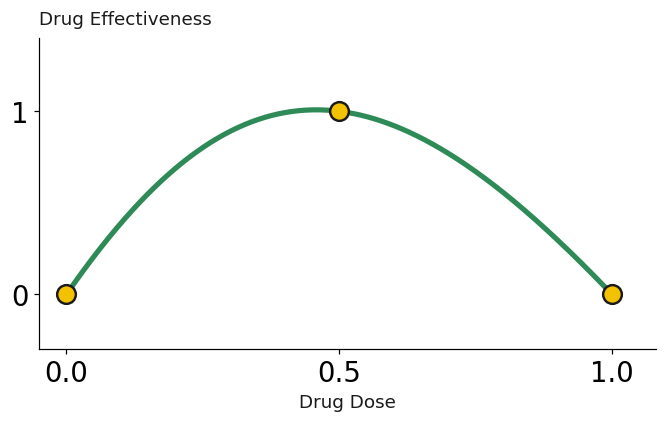

In [37]:
x1, y1, x2, y2, pred = pieces(p)
fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=110)
fig.patch.set_facecolor("white")
d = np.linspace(0, 1, 400)
xs1, xs2 = p["w1"] * d + p["b1"], p["w2"] * d + p["b2"]
fitted = (p["w3"] * np.log(1 + np.exp(xs1))
          + p["w4"] * np.log(1 + np.exp(xs2)) + p["b3"])
ax.set_xlim(-0.05, 1.08)
ax.set_ylim(-0.3, 1.4)
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 1])
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.set_xlabel("Drug Dose", fontsize=12, color=INK)
ax.text(0, 1.03, "Drug Effectiveness", transform=ax.transAxes, ha="left",
        va="bottom", fontsize=12, color=INK)
ax.plot(d, fitted, color=GREEN, lw=3.4, zorder=5)
ax.scatter(dose, observed, s=150, color="#F2C200", edgecolors=INK, lw=1.6,
           zorder=8)
fig.tight_layout()
plt.close(fig)
display(fig)

## REMINDER

### Will this always find the best values?

No. If the SSR looks like this, gradient descent can settle in a
<b style="color:#73000A;">local minimum</b> rather than the
<b style="color:#73000A;">global minimum</b>.

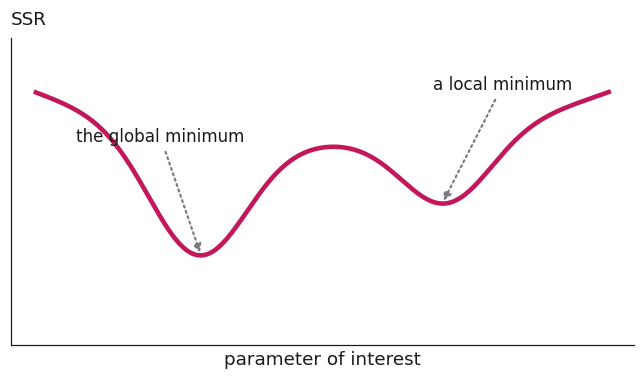

In [38]:
display(fig_local_minimum())

### What to Do About It

1. Try again from different random starting values
2. Try a larger or a smaller learning rate

### How do I choose the learning rate?

If the default does not work, try a range of values. There are functions that
will search for one.

# A SECOND REMINDER

## Why Not Just Set the Derivative to Zero?

## Sometimes We Can

For $w_3$ on its own, the network is <b style="color:#73000A;">linear</b> in
$w_3$:

$$\text{Predicted}_i = (y_{1,i} \times w_3) + (y_{2,i} \times w_4) + b_3$$

Set $\dfrac{d\,\text{SSR}}{d\,w_3} = 0$ and solve. It is least squares with
$y_{1,i}$ as the regressor.

In [39]:
# solve d SSR / d w3 = 0 directly, then check gradient descent agrees
y1, y2 = y_top(DOSE), y_bot(DOSE)
w3_hat = float(((OBS - W4 * y2 - 0.0) @ y1) / (y1 @ y1))

w3 = 0.0
for _ in range(4000):
    pred = w3 * y1 + W4 * y2
    w3 -= 0.01 * float((-2 * (OBS - pred) * y1).sum())

print("closed form       w3 = %.6f" % w3_hat)
print("gradient descent  w3 = %.6f" % w3)
print("difference           = %.2e" % abs(w3_hat - w3))

closed form       w3 = 0.419183
gradient descent  w3 = 0.419183
difference           = 3.33e-16


## And Sometimes We Cannot

$w_1$ sits <b style="color:#73000A;">inside</b> the activation function.

$$\frac{d\,\text{SSR}}{d\,w_1} =
\sum -2(\text{Observed}_i - \text{Predicted}_i)
\times w_3
\times \frac{e^{x_{1,i}}}{1 + e^{x_{1,i}}}
\times \text{Input}_i = 0$$

where $x_{1,i} = (\text{Input}_i \times w_1) + b_1$.

$w_1$ appears inside an exponential, inside a ratio, inside a sum. There is no
rearranging that isolates it.

### It Is the Nesting, Not the Smoothness

SoftPlus is smooth. It has derivatives of every order everywhere.

And we still cannot solve that equation.

The obstacle is that the parameter is buried inside a function inside a sum, not
that anything is badly behaved.

## So What If the Function Is Badly Behaved?

Swap SoftPlus for the <b style="color:#73000A;">ReLU</b>, the activation from
lecture 10.

$$\text{ReLU}(x) = \text{Max}(x,\, 0)$$

It has a corner at $x = 0$, and at that corner it has
<b style="color:#73000A;">no derivative at all</b>.

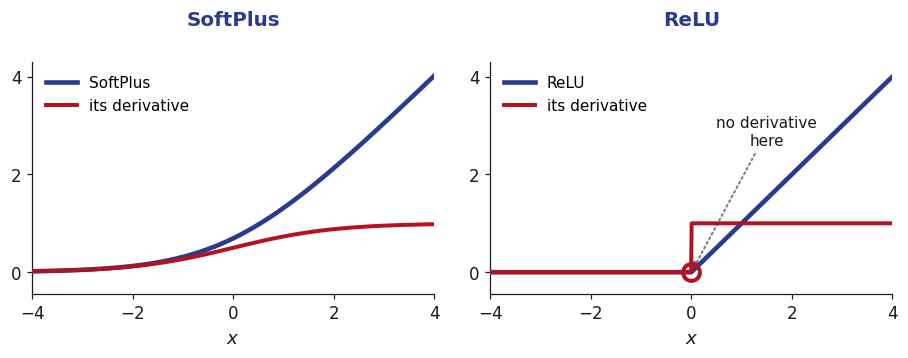

In [40]:
display(fig_two_activations())

### What That Does to the Loss

Sweep $b_1$ and watch the SSR, under each activation.

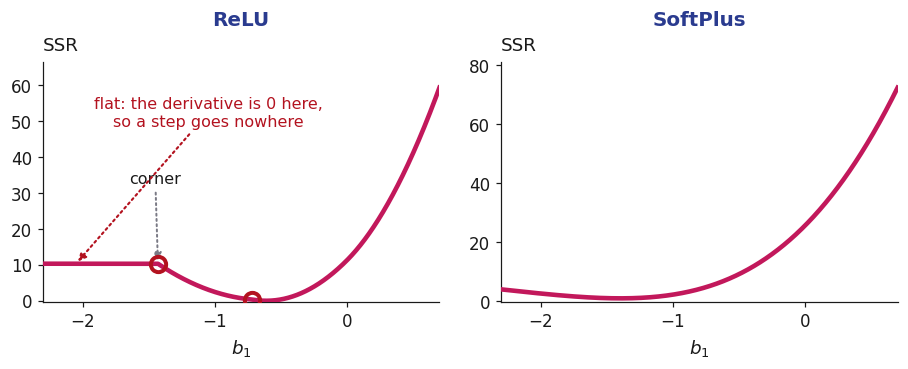

In [41]:
display(fig_loss_shape())

### Gradient Descent Does Not Mind the Corners

The corners are isolated points. A step almost never lands on one, and
if it does we use the value we defined.

Run the same descent under both.

In [47]:
import numpy as np
import pandas as pd

def descend(act, act_prime, start, lr=0.05, steps=1000):
    p = dict(start)
    for _ in range(steps):
        x1, x2 = p["w1"] * DOSE + p["b1"], p["w2"] * DOSE + p["b2"]
        y1, y2 = act(x1), act(x2)
        pred = p["w3"] * y1 + p["w4"] * y2 + p["b3"]
        f = -2 * (OBS - pred)
        g = dict(w1=(f * p["w3"] * act_prime(x1) * DOSE).sum(),
                 b1=(f * p["w3"] * act_prime(x1)).sum(),
                 w2=(f * p["w4"] * act_prime(x2) * DOSE).sum(),
                 b2=(f * p["w4"] * act_prime(x2)).sum(),
                 w3=(f * y1).sum(), w4=(f * y2).sum(), b3=f.sum())
        p = {k: p[k] - lr * g[k] for k in p}
    x1, x2 = p["w1"] * DOSE + p["b1"], p["w2"] * DOSE + p["b2"]
    pred = p["w3"] * act(x1) + p["w4"] * act(x2) + p["b3"]
    return float(((OBS - pred) ** 2).sum())

start = dict(w1=1.43, b1=-0.61, w2=2.63, b2=-0.27, w3=0.0, w4=1.35, b3=0.0)
rows = [(n,
         descend(softplus, sigmoid, start, steps=n),
         descend(relu, relu_step, start, steps=n))
        for n in (100, 1000, 10000, 100000)]
display(pd.DataFrame(rows, columns=["steps", "SoftPlus SSR", "ReLU SSR"])
          .round(6).style.hide(axis="index"))

steps,SoftPlus SSR,ReLU SSR
100,0.659685,0.044822
1000,0.176001,0.000000
10000,0.026251,0.000000
100000,0.000000,0.000000


## What the Corner Does Cost You

Look again at the flat part of the ReLU loss.

If $x_{1,i} < 0$ for <b style="color:#73000A;">every</b> data point, that node
outputs zero for all of them, its derivative is zero, and $w_1$ and
$b_1$ can never move again.

The node is dead, and no number of steps will revive it. Here that happens on
roughly half of all random starts.

In [43]:
rng = np.random.default_rng(11)
counts = {"SoftPlus": [0, 0], "ReLU": [0, 0]}

for _ in range(400):
    w = rng.standard_normal(4)
    start = dict(w1=w[0], b1=0.0, w2=w[1], b2=0.0,
                 w3=w[2], w4=w[3], b3=0.0)
    for name, act, prime in (("SoftPlus", softplus, sigmoid),
                             ("ReLU", relu, relu_step)):
        x1 = start["w1"] * DOSE + start["b1"]
        pred = start["w3"] * act(x1) + start["w4"] * act(
            start["w2"] * DOSE + start["b2"]) + start["b3"]
        g_w1 = float((-2 * (OBS - pred) * start["w3"]
                      * prime(x1) * DOSE).sum())
        counts[name][0] += abs(g_w1) < 1e-12
        counts[name][1] += descend(act, prime, start) < 1e-4

print("out of 400 random starting points")
for name, (dead, ok) in counts.items():
    print("  %-9s  gradient for w1 is zero: %3d     converged: %3d"
          % (name, dead, ok))

out of 400 random starting points
  SoftPlus   gradient for w1 is zero:   0     converged:  22
  ReLU       gradient for w1 is zero: 198     converged: 116


### The Trade

- <b style="color:#73000A;">SoftPlus</b> is smooth and its derivative never
  reaches zero, so no parameter is ever permanently stuck
- <b style="color:#73000A;">ReLU</b> is cheaper to compute and its derivative is
  either $0$ or $1$, which keeps gradients from shrinking through deep networks

Neither can be solved by setting the derivative to zero. That is why we walk
downhill in both cases.

## Key Ideas

- Backpropagation finds a network's weights and biases. Two steps: the chain
  rule for the derivatives, then gradient descent to take the steps
- The derivatives, taken together, are the <b style="color:#73000A;">gradient</b>
- Every derivative is the chain rule applied along the path that links that
  parameter to the loss
- A parameter near the output has a short chain. One near the input has a long
  one, and that is the only thing that changes
- Optimizing more parameters does not change the derivatives already worked out
- The sign of a derivative gives the direction of the step, its size gives the
  length, and the learning rate scales it